# 17 Модификације табеле и записивање табеле у датотеку

### 17.1 Додавање нове врсте или колоне табели

Када у табели израчунамо неке вредности, често је корисно и да их сачувамо. То најлакше радимо тако што табели додајемо нову врсту или колону. Као пример за показивање послужиће нам табела просека оцена по разредима из претходне лекције.

In [1]:
import pandas as pd
школа=[["I",4.56,4.35,4.76,4.78],
      ["II",4.66,4.56,4.76,4.79],
      ["III",4.54,4.56,4.62,4.34],
      ["IV",4.36,4.44,4.55,4.57],
      ["V",4.32,4.23,4.44,4.42],
      ["VI",4.41,4.44,4.53,4.42],
      ["VII",4.23,4.31,4.35,4.32],
      ["VIII",4.45,4.22,4.11,4.35]]
разреди=pd.DataFrame(школа)
разреди.columns=["разред", "Т1", "Т2", "Т3", "Т4"]
разреди1= разреди.set_index("разред")
разреди1

,Т1,Т2,Т3,Т4
разред,,,,
I,4.56,4.35,4.76,4.78
II,4.66,4.56,4.76,4.79
III,4.54,4.56,4.62,4.34
IV,4.36,4.44,4.55,4.57
V,4.32,4.23,4.44,4.42
VI,4.41,4.44,4.53,4.42
VII,4.23,4.31,4.35,4.32
VIII,4.45,4.22,4.11,4.35


Сада желимо да израчунамо просеке свих разреда. Прво нам треба колона у којој ћемо их сачувати. Нова колона се прави на следећи начин:

In [2]:
разреди1["просек разреда"]=0.0
разреди1

,Т1,Т2,Т3,Т4,просек разреда
разред,,,,,
I,4.56,4.35,4.76,4.78,0.0
II,4.66,4.56,4.76,4.79,0.0
III,4.54,4.56,4.62,4.34,0.0
IV,4.36,4.44,4.55,4.57,0.0
V,4.32,4.23,4.44,4.42,0.0
VI,4.41,4.44,4.53,4.42,0.0
VII,4.23,4.31,4.35,4.32,0.0
VIII,4.45,4.22,4.11,4.35,0.0


У следећем кораку ћемо помоћу for циклуса да израчунамо просек сваког разреда, али водићемо рачуна да изаберемо само вредности које нам требају на следећи начин:

In [3]:
for оцена in разреди1.index:
    print(оцена)
    разреди1.loc[оцена, "просек разреда"] = разреди1.loc[оцена, "Т1":"Т4"].mean()
разреди1

I
II
III
IV
V
VI
VII
VIII


,Т1,Т2,Т3,Т4,просек разреда
разред,,,,,
I,4.56,4.35,4.76,4.78,4.6125
II,4.66,4.56,4.76,4.79,4.6925
III,4.54,4.56,4.62,4.34,4.5150
IV,4.36,4.44,4.55,4.57,4.4800
V,4.32,4.23,4.44,4.42,4.3525
VI,4.41,4.44,4.53,4.42,4.4500
VII,4.23,4.31,4.35,4.32,4.3025
VIII,4.45,4.22,4.11,4.35,4.2825


Сада ћемо додати и нову врсту у којој ћемо чувати израчунате вредности просека целе школе у сваком тромесечју.

In [4]:
разреди1.loc["просек школе",]=0.0
разреди1

,Т1,Т2,Т3,Т4,просек разреда
разред,,,,,
I,4.56,4.35,4.76,4.78,4.6125
II,4.66,4.56,4.76,4.79,4.6925
III,4.54,4.56,4.62,4.34,4.5150
IV,4.36,4.44,4.55,4.57,4.4800
V,4.32,4.23,4.44,4.42,4.3525
VI,4.41,4.44,4.53,4.42,4.4500
VII,4.23,4.31,4.35,4.32,4.3025
VIII,4.45,4.22,4.11,4.35,4.2825
просек школе,0.00,0.00,0.00,0.00,0.0000


У следећем кораку треба попунити нову врсту, слично као што смо попуњавали колону.

In [5]:
for kolona in разреди1.columns:
    разреди1.loc["просек школе", kolona] = разреди1.loc["I":"VIII", kolona].mean()
разреди1

,Т1,Т2,Т3,Т4,просек разреда
разред,,,,,
I,4.56000,4.35000,4.760,4.78000,4.612500
II,4.66000,4.56000,4.760,4.79000,4.692500
III,4.54000,4.56000,4.620,4.34000,4.515000
IV,4.36000,4.44000,4.550,4.57000,4.480000
V,4.32000,4.23000,4.440,4.42000,4.352500
VI,4.41000,4.44000,4.530,4.42000,4.450000
VII,4.23000,4.31000,4.350,4.32000,4.302500
VIII,4.45000,4.22000,4.110,4.35000,4.282500
просек школе,4.44125,4.38875,4.515,4.49875,4.460938


In [6]:
тенисер=pd.read_csv("teniser.csv")
тенисер.head(10)

,godina,broj mečeva,broj pobeda
0,2001,56,35
1,2002,76,51
2,2003,78,54
3,2004,81,58
4,2005,89,66
5,2006,91,69
6,2007,95,75
7,2008,110,88
8,2009,121,101
9,2010,122,105


Посматрајмо сада пример учинка једног тенисера у последњих 20 година који је дат у csv фајлу тенисер.csv:

In [7]:
тенисер1=тенисер.set_index("godina")
тенисер1

,broj mečeva,broj pobeda
godina,,
2001,56,35
2002,76,51
2003,78,54
2004,81,58
2005,89,66
2006,91,69
2007,95,75
2008,110,88
2009,121,101


Сада ћемо додати нову колону у којој ћемо чувати проценат успеха и израчунаћемо тај проценат.

In [8]:
тенисер1["učinak"] = 0.0
for i in тенисер1.index:
    тенисер1.loc[i, "učinak"] =100 * тенисер1.loc[i, "broj pobeda"] / тенисер1.loc[i, "broj mečeva"]
тенисер1

,broj mečeva,broj pobeda,učinak
godina,,,
2001,56,35,62.500000
2002,76,51,67.105263
2003,78,54,69.230769
2004,81,58,71.604938
2005,89,66,74.157303
2006,91,69,75.824176
2007,95,75,78.947368
2008,110,88,80.000000
2009,121,101,83.471074


На крају ћемо графички приказати учинак тенисера током година.

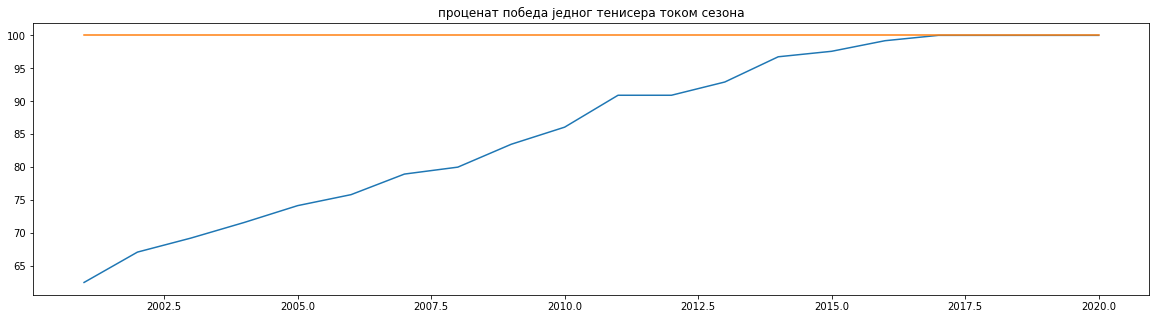

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.plot(тенисер1.index, тенисер1["učinak"])
plt.plot(тенисер1.index, [100.0] * len(тенисер1.index))
plt.title("проценат победа једног тенисера током сезона")
plt.show()
plt.close()

### 17.2 Записивање табеле у датотеку

Врло често нам од користи може бити да податке које смо добили сачувамо у неком фајлу. На примеру табеле тенисер1 ћемо показати како је то могуће.

In [10]:
тенисер1.to_csv("тенисер_1.csv", encoding="utf-8")

Уколико нам индексна колона није потребна, урадићемо следеће:

In [19]:
тенисер1.to_csv("тенисер2.csv", index=False)

### Задаци

#### Задатак 1
Од табеле 8-7-3.xlsx направити csv фајл и из њега формирати табелу у Џупитеру. Након тога индексирати табелу и израчунати просечну цену возила као и просечну старост и ове податке сачувати у новој врсти. На крају транспоновати табелу и сачувати је у csv фајлу.

In [11]:
auto=pd.read_excel("8-7-3.xlsx")
auto.head()

,произвођач,модел,годиште,цена
0,BMW,118d,2009,5200
1,Mercedes,E220,2013,11050
2,Audi,A3,2009,6000
3,Volvo,S60,2015,12500
4,BMW,320i,2012,11900


In [24]:
auto["proiz-model"] = auto["произвођач"] + " - " + auto["модел"]
print(auto.columns)
auto1=auto.loc[:,"годиште ":"proiz-model"]
auto1.head()

Index(['произвођач', 'модел', 'годиште ', 'цена', 'proiz-model'], dtype='object')


,годиште,цена,proiz-model
0,2009,5200,BMW - 118d
1,2013,11050,Mercedes - E220
2,2009,6000,Audi - A3
3,2015,12500,Volvo - S60
4,2012,11900,BMW - 320i


In [25]:
auto1=auto1.set_index("proiz-model")
auto1.head()

,годиште,цена
proiz-model,,
BMW - 118d,2009,5200
Mercedes - E220,2013,11050
Audi - A3,2009,6000
Volvo - S60,2015,12500
BMW - 320i,2012,11900


In [26]:
auto1.loc["Prosek"]=0.0
auto1.tail()

,годиште,цена
proiz-model,,
Volvo - V40,2015.0,9900.0
Audi - Q3,2017.0,17900.0
BMW - X2,2019.0,19900.0
Mercedes - B200,2010.0,8500.0
Prosek,0.0,0.0


In [27]:
for kolona in auto1.columns:
    auto1.loc["Prosek", kolona] = auto1.loc["BMW - 118d":"Mercedes - B200", kolona].mean()
auto1

,годиште,цена
proiz-model,,
BMW - 118d,2009.00,5200.0
Mercedes - E220,2013.00,11050.0
Audi - A3,2009.00,6000.0
Volvo - S60,2015.00,12500.0
BMW - 320i,2012.00,11900.0
Audi - A4,2017.00,18300.0
BMW - 525d,2008.00,7100.0
Volvo - XC60,2014.00,14300.0
Mercedes - C180,2010.00,9250.0


#### Задатак 2
Са свог телефона очитајте број симбола у последњих 10 порука које сте послали кроз СМС, Вибер, ВА, Месенџер и Инстаграм. Од тих података направити табелу, индексирати је и у новим колонама израчунати просечну дужину поруке преко сваког канала. На крају новодобијену табелу сачувати у csv фајлу.

In [29]:
telefoni=[[1,1,6,3,5,11],[2,3,1,6,8,0],[3,2,5,8,23,3],[4,31,45,1,8,7],[5,31,5,1,8,5],[6,123,2,46,3,2],[7,23,234,31,3,1],[8,72,56,346,54,2],[9,234,24,242,2,432],[10,32,1,6,2,5]]
simboli = pd.DataFrame (telefoni)
simboli.columns = ["poruka","sms","viber","va","messenger","instagram"]
simboli.head ()

,poruka,sms,viber,va,messenger,instagram
0,1,1,6,3,5,11
1,2,3,1,6,8,0
2,3,2,5,8,23,3
3,4,31,45,1,8,7
4,5,31,5,1,8,5


In [35]:
simboli1 = simboli.set_index ("poruka")
simboli1.head ()


,sms,viber,va,messenger,instagram
poruka,,,,,
1,1,6,3,5,11
2,3,1,6,8,0
3,2,5,8,23,3
4,31,45,1,8,7
5,31,5,1,8,5


In [36]:
simboli1.loc["prosek",]= 0.0
simboli1.tail ()


,sms,viber,va,messenger,instagram
poruka,,,,,
7,23.0,234.0,31.0,3.0,1.0
8,72.0,56.0,346.0,54.0,2.0
9,234.0,24.0,242.0,2.0,432.0
10,32.0,1.0,6.0,2.0,5.0
prosek,0.0,0.0,0.0,0.0,0.0


In [38]:
for kolona in simboli1.columns:
    simboli1.loc["prosek", kolona] = simboli1.loc[1:10, kolona].mean()
simboli1

,sms,viber,va,messenger,instagram
poruka,,,,,
1,1.0,6.0,3.0,5.0,11.0
2,3.0,1.0,6.0,8.0,0.0
3,2.0,5.0,8.0,23.0,3.0
4,31.0,45.0,1.0,8.0,7.0
5,31.0,5.0,1.0,8.0,5.0
6,123.0,2.0,46.0,3.0,2.0
7,23.0,234.0,31.0,3.0,1.0
8,72.0,56.0,346.0,54.0,2.0
9,234.0,24.0,242.0,2.0,432.0


#### Задатак 3
Направи табелу која садржи висину и масу твојих другара из групе. Након тога направи нову колону у којој ће се рачунати индекс телесне масе као БМИ = маса  / (висина * висина).

In [40]:

osobe=[["osoba1",175,64],["osoba2",181,75],["osoba3",160,50],["osoba4",178,68],["osoba5",190,87]]
bmi=pd.DataFrame(osobe)
bmi.columns=["osoba","visina","masa"]
bmi.head()

,osoba,visina,masa
0,osoba1,175,64
1,osoba2,181,75
2,osoba3,160,50
3,osoba4,178,68
4,osoba5,190,87


In [42]:
bmi1=bmi.set_index("osoba")
bmi1.head()

,visina,masa
osoba,,
osoba1,175,64
osoba2,181,75
osoba3,160,50
osoba4,178,68
osoba5,190,87


In [43]:
bmi1["bmi"]=0.0
bmi1.head()

,visina,masa,bmi
osoba,,,
osoba1,175,64,0.0
osoba2,181,75,0.0
osoba3,160,50,0.0
osoba4,178,68,0.0
osoba5,190,87,0.0


In [46]:
for i in bmi1.index:
    bmi1.loc[i,"bmi"]=bmi1.loc[i,"masa"] / (bmi1.loc[i,"visina"]*bmi1.loc[i,"visina"])
bmi1

,visina,masa,bmi
osoba,,,
osoba1,175,64,0.002090
osoba2,181,75,0.002289
osoba3,160,50,0.001953
osoba4,178,68,0.002146
osoba5,190,87,0.002410


#### Задатак 4 
Са сајта за временску прогнозу који најчешће користиш очитај предвиђену максималну и минималну температуру за Београд за наредних десет дана и представи их табеларно. Након тога додај нову колону која представља највећу температурну разлику у том дану и представи то графички.

#### Задатак 5
У следећој ћелији налазе се подаци о најдужим рекама у Србији. Представити их табеларно, индексирати и додати нову колону која приказује однос квадрата дужине и површине слива.

In [21]:
реке=[["Дунав",2888,817000],
     ["Тиса",1026,157020],
     ["Сава",990,95719],
     ["Велика Морава",493,35419],
     ["Дрина",487,19570],
     ["Тамиш",359,13085],
     ["Дрим",335,11756],
     ["Јужна Морава",295,15469],
     ["Ибар",276,8059],
     ["Млава",263,17632]]

#### Задатак 6
У следећој ћелији је дата табела из прошле лекције о трошковима једне фирме. Израчунати укупне месечне трошкове и укупне трошкове по ставкама и све то сачувати у табели коју ћете извести у csv формату. Приказати податке графички.

In [20]:
трошкови=[["плате",1100210,1105000,1140200,1050400,1000500,980300,1101400,1240200,1325700,1239800,1323400,1345670],
         ["најам канцеларије",120000,120000,120000,80000,80000,80000,120000,120000,120000,120000,120000,120000],
         ["возни парк",75000,70000,74000,50000,51000,49000,77000,76000,79000,81000,82000,80500],
         ["потрошни материјал",10000,11000,12500,12000,9000,8000,10000,11000,12000,12300,11600,11900],
         ["телефони и интернет",20000,21000,21500,25000,27000,31000,25000,26000,25000,24500,26000,25550],
         ["остало",3500,4300,3200,4200,3900,1300,3230,5000,6500,3500,2300,4700]]